# Linear Decision Boundaries

**classification** - learning to predict discrete labels
**decision boundary** - the surface separating different predicted classes
**linear classifier** - a classifier that learns linear decision boundaries
**linearly separable** - a dataset that can be perfectly explained by a linear classifier

In [48]:
# Excurse - the dot product
import numpy as np

x = np.arange(3)
y = np.arange(3,6)

x*y

array([ 0,  4, 10])

In [49]:
print(np.sum(x*y))
print(x@y) # x dot y

14
14


In [50]:
# load dataset

from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()
X, y = dataset.data, dataset.target

In [51]:
# Predictions with LogisticRegression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X,y)

print(model.predict(X)[10])
print(model.predict(X)[20])

0
1


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
# raw model output
model.coef_ @ X[10] + model.intercept_

array([-6.48900641])

In [53]:
model.coef_ @ X[20] + model.intercept_

array([5.37579574])

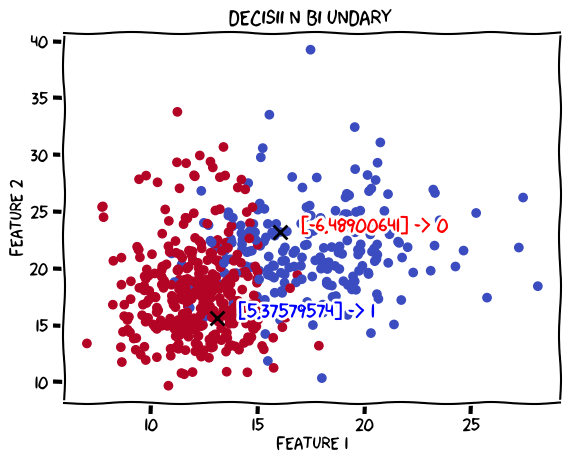

In [54]:
# Visualize the decision boundary

import matplotlib.pyplot as plt

plt.xkcd()
plt.title('Decision Boundary')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')

# add the samples for 10 and 20 to the plot
plt.scatter(X[10,0], X[10,1], c='black', marker='x', s=100)
plt.scatter(X[20,0], X[20,1], c='black', marker='x', s=100)
# annotate the two samples with the actual predictions
label10 = str(model.coef_ @ X[10] + model.intercept_) + ' -> ' + str(model.predict(X)[10])
label20 = str(model.coef_ @ X[20] + model.intercept_) + ' -> ' + str(model.predict(X)[20])

plt.annotate(label10, (X[10,0] + 1, X[10,1]), fontsize=16, color='red')
plt.annotate(label20, (X[20,0] + 1, X[20,1]), fontsize=16, color='blue')

plt.show()